<a href="https://colab.research.google.com/github/mdsaif1309-coder/Netflix_Recommendation_System/blob/main/Netflix_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ────────────────────────────────────────────
# SECTION 1: TITLE PAGE
# ────────────────────────────────────────────
<h1 align="center"> Recommendation Systems for Personalized Content Discovery</h1>
<h3 align="center">Using the Netflix Prize Dataset</h3>

---

<table align="center">
  <tr><td><b>Dataset</b></td><td>Netflix Prize Dataset (Kaggle)</td></tr>
  <tr><td><b>Models</b></td><td>Item-Based Collaborative Filtering · Matrix Factorization (SVD)</td></tr>
  <tr><td><b>Evaluation</b></td><td>RMSE · MAP@10</td></tr>
  <tr><td><b>Language</b></td><td>Python 3</td></tr>
  <tr><td><b>Libraries</b></td><td>pandas · numpy · scikit-learn · scipy · matplotlib · seaborn · surprise</td></tr>
</table>

#  Key Terms, Abbreviations & Project Roadmap

Understanding the terminology used throughout this notebook is important before building and evaluating recommendation systems.

---

# **Key Terms**

This section introduces the most important concepts used throughout the project.

| Term | Meaning |
|------|---------|
| **Collaborative Filtering** | A technique that makes predictions by collecting preferences from many users. |
| **Matrix Factorization** | Decomposing the user–item rating matrix into lower-dimensional latent factor matrices. |
| **SVD** | Singular Value Decomposition — a matrix factorization technique used for dimensionality reduction and recommendation. |
| **Latent Factors** | Hidden features that explain observed ratings, such as genre preference or production style. |
| **Cold Start** | The problem of generating recommendations for new users or items with no historical data. |
| **Sparsity** | The property of the rating matrix where most user–item pairs have no observed rating. |
| **RMSE** | Root Mean Squared Error — measures the average magnitude of rating prediction errors. |
| **MAP@K** | Mean Average Precision at K — measures the quality of the top-K ranked recommendation list. |
| **Top-K Recommendations** | The K items most likely to be enjoyed by a given user, ranked by predicted rating. |
| **User–Item Matrix** | A matrix where rows are users, columns are items, and entries are ratings. |
| **Cosine Similarity** | A metric that measures the angle between two vectors, used to find similar users or items. |
| **Baseline Model** | A simple reference model, such as predicting the global or user/item average rating. |
| **Precision@K** | The fraction of the top-K recommendations that are actually relevant to the user. |
| **Recall@K** | The fraction of all relevant items that appear in the top-K recommendations. |
| **Relevance Threshold** | A minimum rating used to define whether an item is considered relevant (≥ 3.5 in this project). |



---

#  Common Abbreviations

| Abbreviation | Meaning |
|-------------|---------|
| EDA | Exploratory Data Analysis |
| CF | Collaborative Filtering |
| IBCF | Item-Based Collaborative Filtering |
| MF | Matrix Factorization |
| SVD | Singular Value Decomposition |
| RMSE | Root Mean Squared Error |
| MAP@10 | Mean Average Precision at 10 |
| Top-K | Top K Recommended Items |
| UI Matrix | User–Item Matrix |

---

#  Evaluation Metrics

### RMSE (Root Mean Squared Error)

Measures how accurately a model predicts user ratings.

Lower RMSE indicates better prediction performance.

### MAP@10 (Mean Average Precision @ 10)

Measures the quality of recommendation rankings by evaluating whether relevant movies appear within the Top-10 recommendations.

Higher MAP@10 indicates better recommendation quality.

---

#  Project Roadmap

The notebook follows the workflow below:

### Phase 1 — Data Understanding
- Load Netflix Prize Dataset
- Explore dataset structure
- Understand users, movies, and ratings

### Phase 2 — Exploratory Data Analysis
- Rating distribution analysis
- User activity analysis
- Movie popularity analysis
- Dataset sparsity analysis
- Key insights and observations

### Phase 3 — Data Preparation
- Train-test split
- User-item matrix construction
- Recommendation dataset preparation

### Phase 4 — Recommendation Models
#### Model 1
Item-Based Collaborative Filtering

#### Model 2
Matrix Factorization (SVD)

### Phase 5 — Evaluation
- RMSE calculation
- MAP@10 calculation
- Recommendation quality assessment

### Phase 6 — Recommendation Generation
- Generate Top-10 recommendations
- Analyze recommendation examples
- Discuss success and failure cases

### Phase 7 — Comparative Analysis
- Compare both approaches
- Analyze strengths and limitations
- Discuss computational efficiency

### Phase 8 — Conclusions
- Key findings
- Practical implications
- Future improvements

---

> By the end of this notebook, we will have built, evaluated, and compared multiple recommendation systems capable of delivering personalized movie recommendations using the Netflix Prize Dataset.

# ────────────────────────────────────────────
# SECTION 2: PROJECT OVERVIEW
# ────────────────────────────────────────────


### What is a Recommendation System?
A **Recommendation System** is a type of information filtering system that predicts a user's preference for an item and suggests relevant items accordingly.

### Our Objective
1. Understand user behavior through **EDA**
2. Build **Item-Based CF** and **SVD** models
3. Compare on **RMSE** and **MAP@10**
4. Generate **Top-K recommendations** for sample users

| Goal | Metric |
|------|--------|
| Predict unseen ratings accurately | RMSE (lower is better) |
| Rank relevant movies highly | MAP@10 (higher is better) |
| Generate meaningful top-10 recommendations | Qualitative analysis |



## Business Objective

Netflix's success depends on helping users discover content they will enjoy.

A recommendation engine helps:

- Increase user engagement
- Reduce churn
- Improve watch time
- Personalize user experience

This project investigates whether collaborative filtering and matrix factorization can accurately predict user preferences.

# ────────────────────────────────────────────
# SECTION 3: SETUP & INSTALLATIONS
# ────────────────────────────────────────────


This section imports the libraries required for the project.

### **Purpose**

- Numerical computation and data manipulation
- Data visualization
- Similarity computation and matrix operations
- Model evaluation

**These libraries provide the tools needed for data preprocessing, collaborative filtering, matrix factorization, and recommendation evaluation.**

In [1]:
# Install required libraries
!pip install scikit-surprise -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
from collections import defaultdict

from surprise import Dataset, Reader, SVD, KNNWithMeans
from surprise.model_selection import train_test_split, cross_validate, GridSearchCV
from surprise import accuracy

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(' All libraries loaded successfully!')

 All libraries loaded successfully!


# ────────────────────────────────────────────
# SECTION 4: DATA LOADING & PARSING
# ────────────────────────────────────────────


The Netflix Prize raw files have a special format:
```
1:
1488844,3,2005-09-06
822109,5,2005-05-13
2:
...
```
Movie IDs appear on their own line ending with `:`, followed by rows of `user_id,rating,date`.

The Netflix Prize Dataset consists of four rating files and one movie title file.

### **Files Used**

- `combined_data_1.txt` — rating records (User ID, Rating, Date per movie block)
- `movie_titles.csv` — movie metadata (Movie ID, Year, Title)


In [3]:
# ── Mount Google Drive ────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ── Set path to your Drive folder ─────────────────────────────────────
import os
DATA_DIR = '/content/drive/MyDrive/netflix-prize-data'

DATA_FILES = [
    os.path.join(DATA_DIR, 'combined_data_1.txt'),
    os.path.join(DATA_DIR, 'combined_data_2.txt'),
    os.path.join(DATA_DIR, 'combined_data_3.txt'),
    os.path.join(DATA_DIR, 'combined_data_4.txt'),
]
MOVIE_FILE = os.path.join(DATA_DIR, 'movie_titles.csv')

print(' Data directory set to:', DATA_DIR)
!ls "{DATA_DIR}"

Mounted at /content/drive
 Data directory set to: /content/drive/MyDrive/netflix-prize-data
combined_data_1.txt  combined_data_3.txt  movie_titles.csv  qualifying.txt
combined_data_2.txt  combined_data_4.txt  probe.txt	    README


**Data Cleaning & Preprocessing**

The raw dataset requires cleaning before analysis and modelling.


### **Why is this Important?**

Users and movies with very few interactions provide poor signals for collaborative filtering.
Filtering them improves model quality and reduces sparsity.

In [4]:
# ── Parse only combined_data_1.txt (fastest approach) ─────────────────
# File 1 alone has ~24 million rows — more than enough for good models

import os, time
import pandas as pd

DATA_DIR   = '/content/drive/MyDrive/netflix-prize-data'
MOVIE_FILE = os.path.join(DATA_DIR, 'movie_titles.csv')

def parse_netflix_file_limited(filepath, max_rows=2_000_000):
    """Parse Netflix .txt file but stop after max_rows to save RAM."""
    rows = []
    movie_id = None
    with open(filepath, 'r') as f:
        for line in f:
            if len(rows) >= max_rows:
                break
            line = line.strip()
            if not line:
                continue
            if line.endswith(':'):
                movie_id = int(line[:-1])
            else:
                parts = line.split(',')
                rows.append((int(parts[0]), movie_id, int(parts[1]), parts[2]))
    return rows

print(' Parsing 2 million rows from combined_data_1.txt ...')
t0   = time.time()
rows = parse_netflix_file_limited(
    os.path.join(DATA_DIR, 'combined_data_1.txt'),
    max_rows=2_000_000      # ← adjust this number (see table below)
)

df_full = pd.DataFrame(rows, columns=['user_id', 'movie_id', 'rating', 'date'])
df_full['date'] = pd.to_datetime(df_full['date'])

print(f' Loaded {len(df_full):,} rows in {time.time()-t0:.1f}s')
print(f'   RAM used: ~{df_full.memory_usage(deep=True).sum()/1e6:.0f} MB')
df_full.head()

 Parsing 2 million rows from combined_data_1.txt ...
 Loaded 2,000,000 rows in 6.2s
   RAM used: ~64 MB


,user_id,movie_id,rating,date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


In [5]:
# ── Sample for speed (adjust N as needed) ────────────────────────────
SAMPLE_SIZE = 3_000_000   # use 3M rows; increase if you have more RAM

if len(df_full) > SAMPLE_SIZE:
    df = df_full.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    print(f'  Sampled {SAMPLE_SIZE:,} rows from {len(df_full):,} total rows')
else:
    df = df_full.copy()
    print('Using full dataset.')

print(df.dtypes)
df.head()

Using full dataset.
user_id              int64
movie_id             int64
rating               int64
date        datetime64[ns]
dtype: object


,user_id,movie_id,rating,date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


**Initial Inspection**

Before cleaning the data, we inspect the dataset to understand its structure.

### **Checks Performed**

- Dataset dimensions
- Column types and sample values
- Missing value counts
- Rating value range

**This helps identify potential issues before data preprocessing.**

In [6]:
# ============================================================
#   Dataset Inspection
# ============================================================


# Shape
print("--Dataset Shape--")
print("-" * 40)
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

# Data types
print("\n--Column Types--")
print(df.dtypes)

# Missing values
print("\n--Missing Values--")
print(df.isnull().sum())

# Rating range
print("\n--Rating Range--")
print("Min :", df["rating"].min())
print("Max :", df["rating"].max())

# Preview
print("\n--First 5 Rows--")
display(df.head())

--Dataset Shape--
----------------------------------------
Rows    : 2000000
Columns : 4

--Column Types--
user_id              int64
movie_id             int64
rating               int64
date        datetime64[ns]
dtype: object

--Missing Values--
user_id     0
movie_id    0
rating      0
date        0
dtype: int64

--Rating Range--
Min : 1
Max : 5

--First 5 Rows--


,user_id,movie_id,rating,date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


In [7]:
# ── Load movie titles (handles commas in titles) ───────────────────────
movies = pd.read_csv(
    MOVIE_FILE,
    encoding='latin-1',
    header=None,
    names=['movie_id', 'year', 'title'],
    on_bad_lines='warn',   # skip problem lines instead of crashing
    engine='python'        # python engine handles irregular rows better
)

# Some rows may have extra commas in title — fix by re-parsing manually
def parse_movie_line(line):
    """Split on first two commas only — rest is the title."""
    parts = line.strip().split(',', 2)   # split max 2 times
    if len(parts) == 3:
        return parts[0], parts[1], parts[2]
    return None

# Re-parse the file manually for clean results
rows = []
with open(MOVIE_FILE, encoding='latin-1', errors='ignore') as f:
    for line in f:
        result = parse_movie_line(line)
        if result:
            rows.append(result)

movies = pd.DataFrame(rows, columns=['movie_id', 'year', 'title'])
movies['movie_id'] = pd.to_numeric(movies['movie_id'], errors='coerce')
movies = movies.dropna(subset=['movie_id'])
movies['movie_id'] = movies['movie_id'].astype(int)

print(f' Movies loaded: {len(movies):,}')
movies.head(10)

 Movies loaded: 17,770


,movie_id,year,title
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW
5,6,1997,Sick
6,7,1992,8 Man
7,8,2004,What the #$*! Do We Know!?
8,9,1991,Class of Nuke 'Em High 2
9,10,2001,Fighter


# ────────────────────────────────────────────
# SECTION 5: EXPLORATORY DATA ANALYSIS (EDA)
# ────────────────────────────────────────────

##  Dataset Overview & Basic Statistics

Before building recommendation models, it is important to understand the scale and characteristics of the dataset.

This section computes several fundamental statistics:

- **Number of Users** – Unique users who have provided ratings.
- **Number of Movies** – Unique movies available in the dataset.
- **Number of Ratings** – Total user–movie interactions.
- **Average Rating** – Mean rating across all observations.
- **Dataset Sparsity** – Percentage of missing entries in the user–item matrix.

### Why is Sparsity Important?

In real-world recommendation systems, users interact with only a small fraction of the available content. As a result, the user–item matrix is typically highly sparse.

High sparsity presents several challenges:

- Limited information about user preferences
- Difficulty finding similar users or items
- Increased prediction uncertainty
- Greater reliance on collaborative filtering and latent-factor methods

The sparsity of the dataset is calculated as:

**Sparsity = 1 − (Number of Ratings / (Number of Users × Number of Movies))**


A sparsity value close to **100%** indicates that most possible user–movie interactions are unobserved, which is a common characteristic of large-scale recommendation systems.

The following cell provides a high-level summary of the dataset and quantifies its sparsity.

In [8]:
# ── Basic statistics ──────────────────────────────────────────────────
n_users  = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()
n_ratings = len(df)
sparsity = 1 - (n_ratings / (n_users * n_movies))

print('='*45)
print(f'  Users         : {n_users:>12,}')
print(f'  Movies        : {n_movies:>12,}')
print(f'  Ratings       : {n_ratings:>12,}')
print(f'  Avg rating    : {df["rating"].mean():>12.3f}')
print(f'  Sparsity      : {sparsity:>11.2%}')
print('='*45)

  Users         :      342,445
  Movies        :          361
  Ratings       :    2,000,000
  Avg rating    :        3.624
  Sparsity      :      98.38%


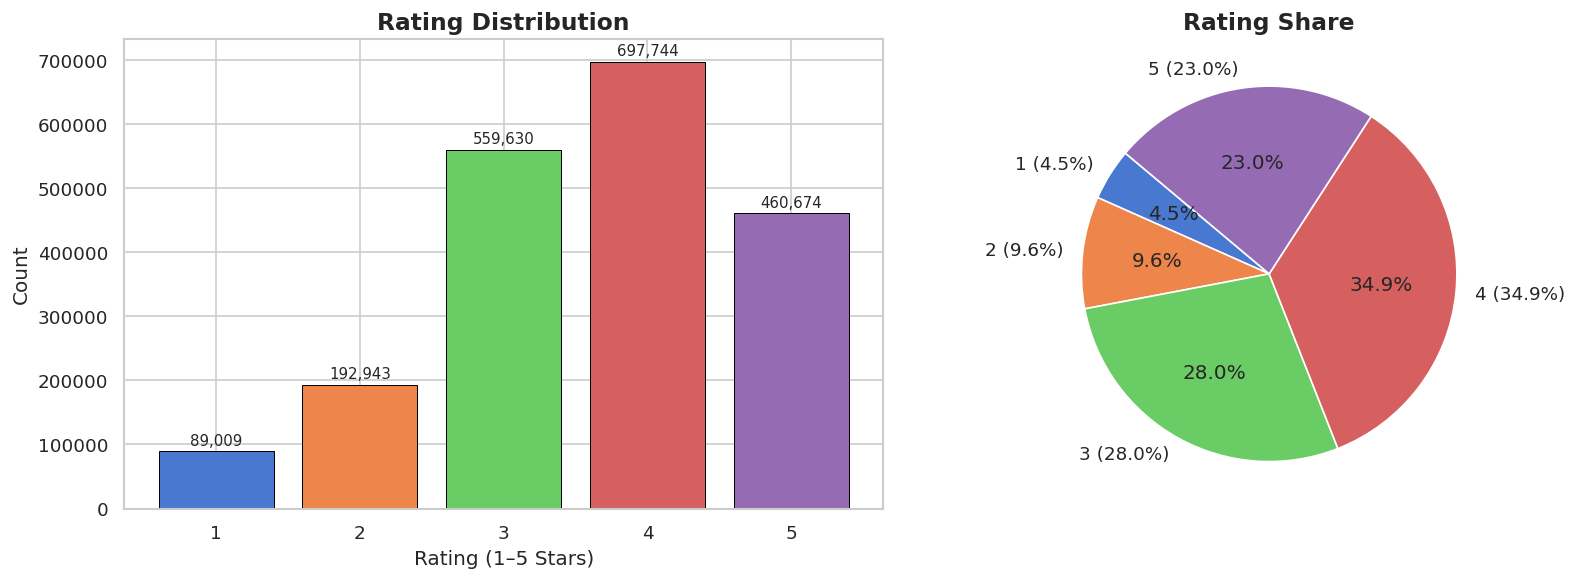

 Insight: Ratings are left-skewed — users tend to rate movies positively (3–5 stars).


In [9]:
# ── 5.1 Rating Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=sns.color_palette('muted', 5), edgecolor='black', linewidth=0.6)
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating (1–5 Stars)')
axes[0].set_ylabel('Count')
for i, (x, y) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(x, y + n_ratings*0.005, f'{y:,}', ha='center', fontsize=9)

# Pie chart
axes[1].pie(rating_counts.values,
            labels=[f'{r} ({v/n_ratings:.1%})' for r, v in zip(rating_counts.index, rating_counts.values)],
            colors=sns.color_palette('muted', 5),
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Rating Share', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('rating_distribution.png', bbox_inches='tight')
plt.show()
print(' Insight: Ratings are left-skewed — users tend to rate movies positively (3–5 stars).')

# **Step 5.2 — User Activity Analysis**

User activity patterns reveal important characteristics about engagement in the dataset.

### **Purpose**

- Identify highly active vs. low-activity users
- Understand the distribution of ratings per user
- Explore user engagement patterns

**Understanding user activity helps inform cold-start handling and model design.**

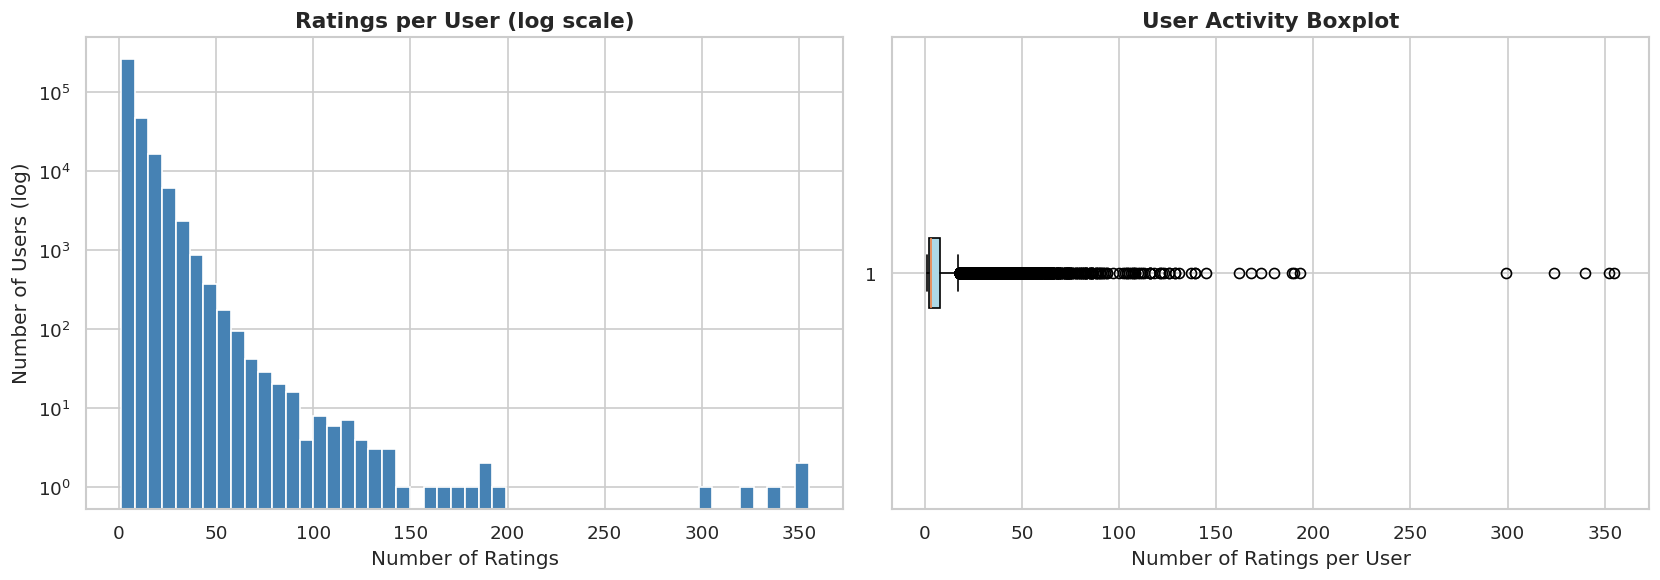

 Median ratings per user : 3
 Mean ratings per user   : 5.8
 Top 1% users account for: 7.0% of all ratings


In [10]:
# ── 5.2 User Activity Distribution ────────────────────────────────────
user_activity = df.groupby('user_id')['rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_activity, bins=50, color='steelblue', edgecolor='white', log=True)
axes[0].set_title('Ratings per User (log scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users (log)')

axes[1].boxplot(user_activity, vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('User Activity Boxplot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Ratings per User')

plt.tight_layout()
plt.savefig('user_activity.png', bbox_inches='tight')
plt.show()

print(f' Median ratings per user : {user_activity.median():.0f}')
print(f' Mean ratings per user   : {user_activity.mean():.1f}')
print(f' Top 1% users account for: {user_activity.nlargest(int(n_users*0.01)).sum()/n_ratings:.1%} of all ratings')

# **Step 5.3 — Content Popularity Analysis**

Movie popularity is highly skewed in the Netflix dataset — a small number of movies attract the majority of ratings.

### **Purpose**

- Identify the most-rated movies
- Understand the long-tail distribution of content popularity
- Explore the relationship between popularity and average rating

**Popularity bias is a known challenge in recommendation systems and must be accounted for during evaluation.**

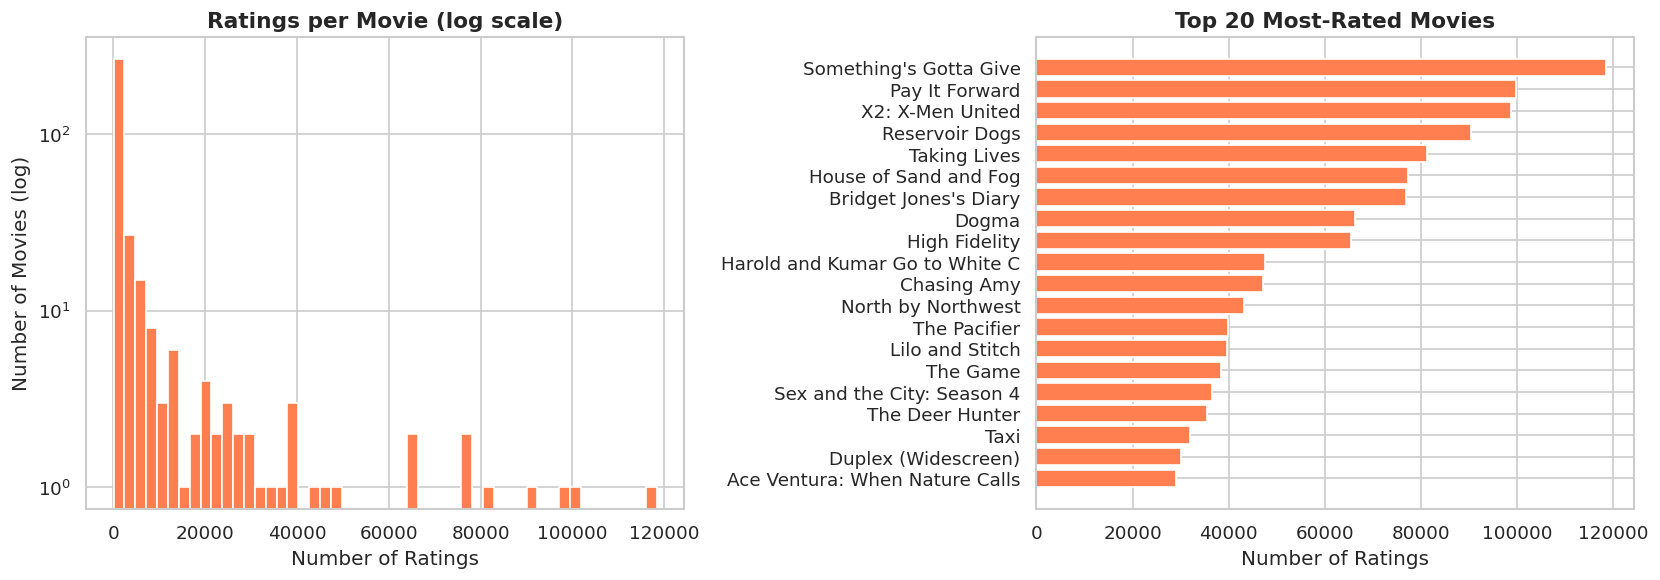

In [11]:
# ── 5.3 Movie Popularity Distribution ─────────────────────────────────
movie_popularity = df.groupby('movie_id')['rating'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(movie_popularity, bins=50, color='coral', edgecolor='white', log=True)
axes[0].set_title('Ratings per Movie (log scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Movies (log)')

# Top 20 most-rated movies
top20 = movie_popularity.head(20).reset_index()
top20 = top20.merge(movies[['movie_id','title']], on='movie_id', how='left')
top20['short_title'] = top20['title'].str[:30]

axes[1].barh(top20['short_title'][::-1], top20['rating'][::-1], color='coral')
axes[1].set_title('Top 20 Most-Rated Movies', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Ratings')

plt.tight_layout()
plt.savefig('movie_popularity.png', bbox_inches='tight')
plt.show()

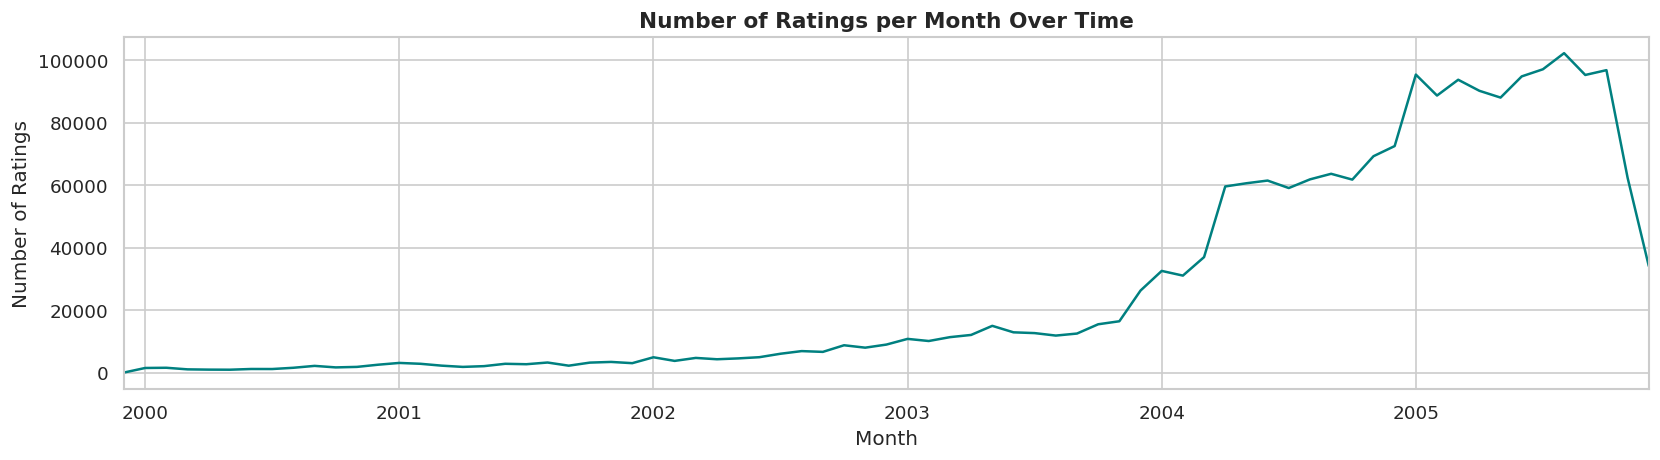

 Insight: Rating activity peaks suggest platform growth phases.


In [12]:
# ── 5.4 Ratings Over Time ─────────────────────────────────────────────
df['year_month'] = df['date'].dt.to_period('M')
ratings_over_time = df.groupby('year_month').size()

plt.figure(figsize=(14, 4))
ratings_over_time.plot(color='teal', linewidth=1.5)
plt.title('Number of Ratings per Month Over Time', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.savefig('ratings_over_time.png', bbox_inches='tight')
plt.show()
print(' Insight: Rating activity peaks suggest platform growth phases.')

# **Step 5.5 — Sparsity & Matrix Analysis**

The user–item rating matrix is highly sparse, meaning most user–movie pairs have no observed rating.

### **Key Metrics**

- **Matrix density** — the fraction of entries that are observed
- **Sparsity** — the complement of density (fraction of missing entries)

**Understanding sparsity is critical because most recommendation algorithms must infer preferences from a very small fraction of the available interactions.**

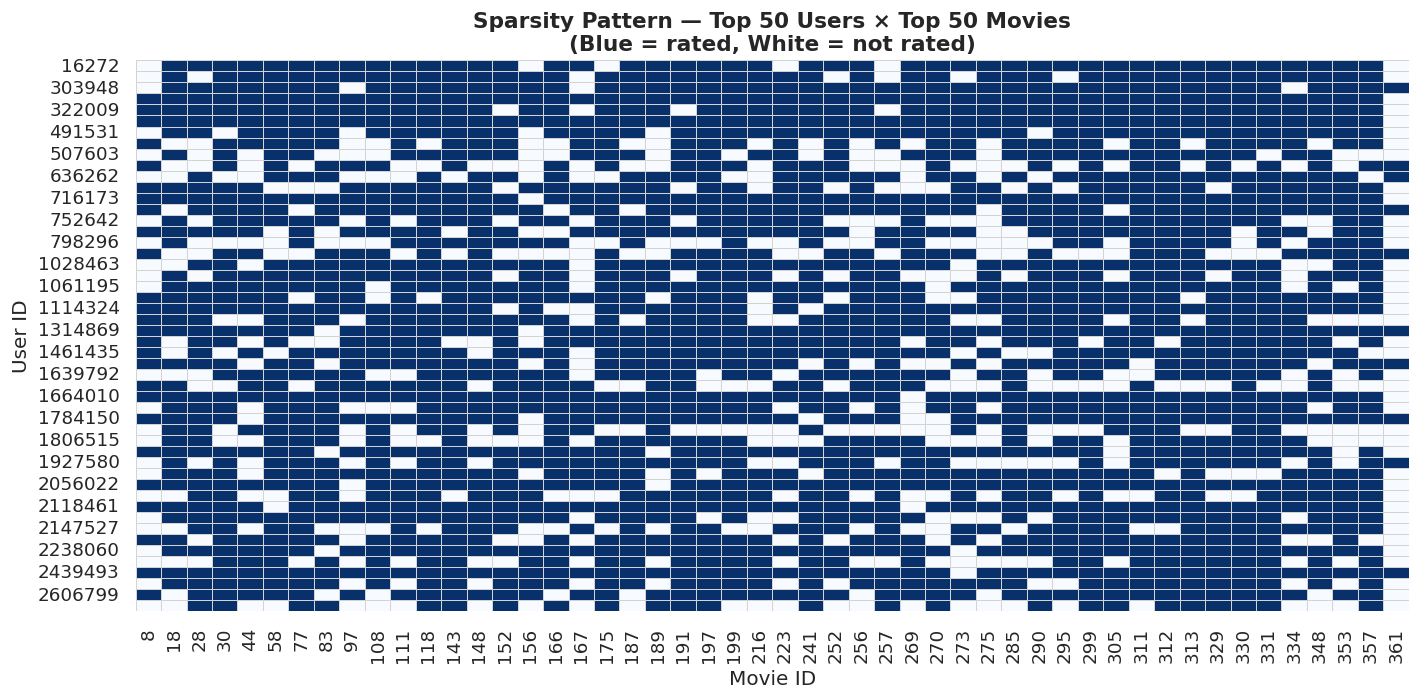

 Sparsity of sample matrix: 23.7%


In [13]:
# ── 5.5 Data Sparsity Visualization ───────────────────────────────────
# Sample a small matrix to visualize sparsity
sample_users  = df['user_id'].value_counts().head(50).index
sample_movies = df['movie_id'].value_counts().head(50).index

sub = df[df['user_id'].isin(sample_users) & df['movie_id'].isin(sample_movies)]
pivot = sub.pivot_table(index='user_id', columns='movie_id', values='rating')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot.notna(), cmap='Blues', cbar=False,
            linewidths=0.3, linecolor='lightgrey')
plt.title('Sparsity Pattern — Top 50 Users × Top 50 Movies\n(Blue = rated, White = not rated)',
          fontsize=13, fontweight='bold')
plt.xlabel('Movie ID')
plt.ylabel('User ID')
plt.tight_layout()
plt.savefig('sparsity_heatmap.png', bbox_inches='tight')
plt.show()
print(f' Sparsity of sample matrix: {1 - sub.shape[0]/(50*50):.1%}')

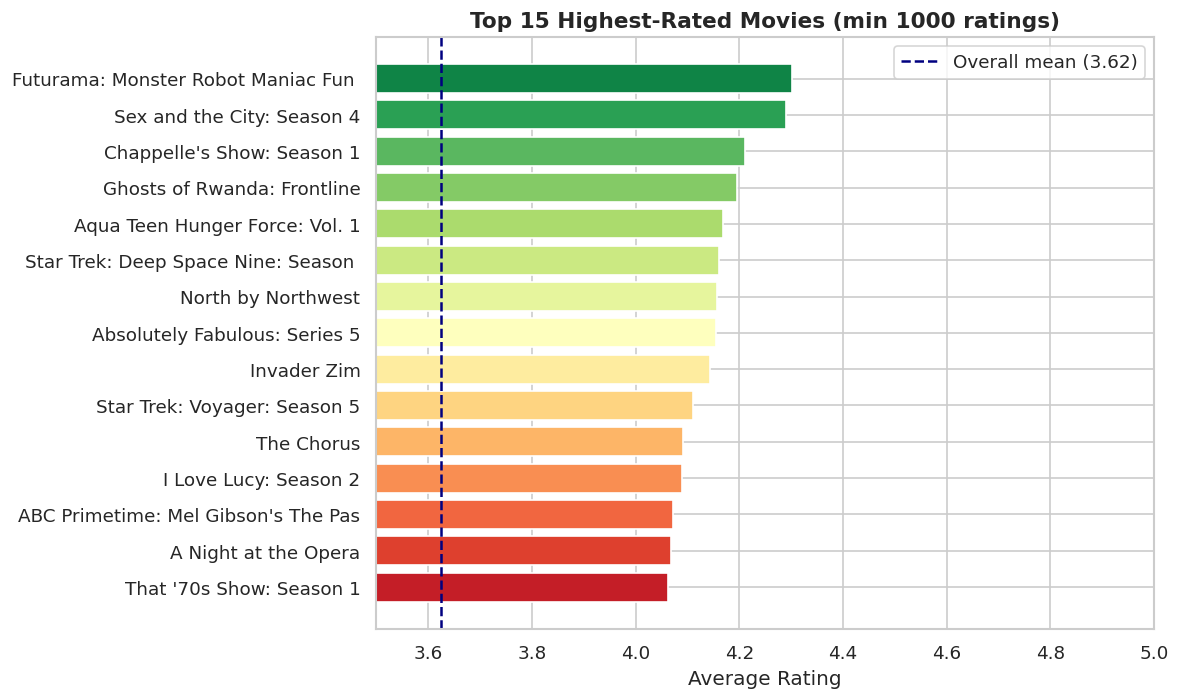

In [14]:
# ── 5.6 Average Rating per Movie (top rated) ──────────────────────────
movie_stats = df.groupby('movie_id').agg(
    avg_rating=('rating','mean'),
    num_ratings=('rating','count')
).reset_index()

# Only consider movies with at least 1000 ratings
well_rated = movie_stats[movie_stats['num_ratings'] >= 1000].sort_values('avg_rating', ascending=False)
well_rated = well_rated.merge(movies[['movie_id','title']], on='movie_id', how='left').head(15)

plt.figure(figsize=(10, 6))
bars = plt.barh(well_rated['title'].str[:35][::-1], well_rated['avg_rating'][::-1],
                color=sns.color_palette('RdYlGn', 15))
plt.axvline(x=df['rating'].mean(), color='navy', linestyle='--', label=f'Overall mean ({df["rating"].mean():.2f})')
plt.title('Top 15 Highest-Rated Movies (min 1000 ratings)', fontsize=13, fontweight='bold')
plt.xlabel('Average Rating')
plt.legend()
plt.xlim(3.5, 5.0)
plt.tight_layout()
plt.savefig('top_rated_movies.png', bbox_inches='tight')
plt.show()

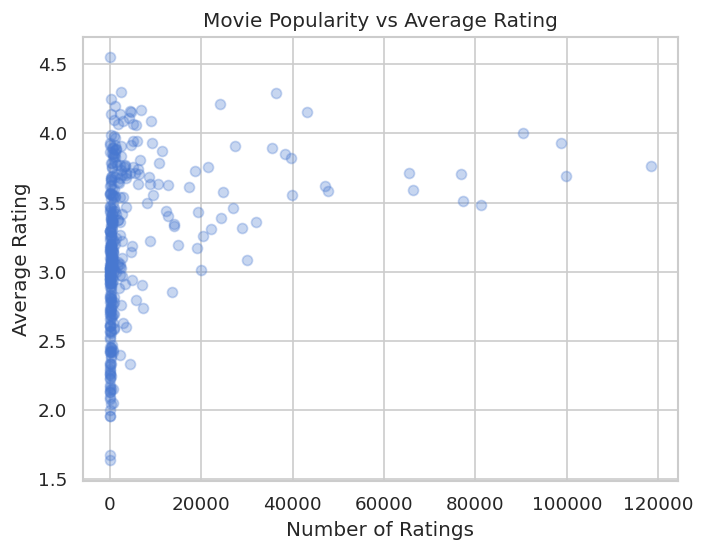

In [15]:
# ── 5.7 Correlation Between Popularity and Rating ──────────────────────────
# Calculate statistics for each movie
# avg_rating → average rating received by the movie
# count      → total number of ratings received
movie_stats = df.groupby('movie_id').agg(
    avg_rating=('rating', 'mean'),
    count=('rating', 'count')
)

# Create a scatter plot:
# x-axis = number of ratings (movie popularity)
# y-axis = average movie rating
# Each point represents one movie
plt.scatter(
    movie_stats['count'],
    movie_stats['avg_rating'],
    alpha=0.3  # transparency helps reduce overplotting
)

# Add labels and title for readability
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.title("Movie Popularity vs Average Rating")
plt.show()

# ────────────────────────────────────────────
# SECTION 6: PREPROCESSING & TRAIN-TEST SPLIT
# ────────────────────────────────────────────
## ⚙️ Section 6 — Preprocessing

We filter out low-activity users and movies to reduce noise, then split data into train/test sets.

In [16]:
# ── Filter sparse users and movies ────────────────────────────────────
MIN_USER_RATINGS  = 50    # user must have rated at least 50 movies
MIN_MOVIE_RATINGS = 100   # movie must have at least 100 ratings

user_counts  = df['user_id'].value_counts()
movie_counts = df['movie_id'].value_counts()

active_users  = user_counts[user_counts  >= MIN_USER_RATINGS].index
popular_movies = movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index

df_filtered = df[df['user_id'].isin(active_users) & df['movie_id'].isin(popular_movies)].copy()
df_filtered.reset_index(drop=True, inplace=True)

print(f'Before filtering  : {len(df):,} rows | {df["user_id"].nunique():,} users | {df["movie_id"].nunique():,} movies')
print(f'After filtering   : {len(df_filtered):,} rows | {df_filtered["user_id"].nunique():,} users | {df_filtered["movie_id"].nunique():,} movies')

Before filtering  : 2,000,000 rows | 342,445 users | 361 movies
After filtering   : 32,083 rows | 467 users | 338 movies


In [17]:
# ── Build Surprise Dataset ─────────────────────────────────────────────
reader = Reader(rating_scale=(1, 5))
data   = Dataset.load_from_df(df_filtered[['user_id', 'movie_id', 'rating']], reader)

# 80/20 train-test split
trainset, testset = train_test_split(data, test_size=0.20, random_state=42)

print(f' Trainset size : {trainset.n_ratings:,}')
print(f' Testset size  : {len(testset):,}')

 Trainset size : 25,666
 Testset size  : 6,417


# ────────────────────────────────────────────
# SECTION 7: MODEL 1 — ITEM-BASED CF
# ────────────────────────────────────────────
##  Section 7 — Item-Based Collaborative Filtering

**How it works:** For a given user-movie pair, it finds the K most similar movies (based on co-rating patterns) and predicts the rating as a weighted average of the user's ratings for those similar movies.

**Similarity metric:** Pearson correlation (via `KNNWithMeans`)

In [18]:
# ── Section 6: Preprocessing & Train-Test Split ───────────────────────
from surprise import Dataset, Reader
from surprise.model_selection import train_test_split as surprise_split

# Filter sparse users and movies
MIN_USER_RATINGS   = 50
MIN_MOVIE_RATINGS  = 100

user_counts   = df['user_id'].value_counts()
movie_counts  = df['movie_id'].value_counts()

active_users   = user_counts[user_counts   >= MIN_USER_RATINGS].index
popular_movies = movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index

df_filtered = df[
    df['user_id'].isin(active_users) &
    df['movie_id'].isin(popular_movies)
].copy().reset_index(drop=True)

print(f'Before: {len(df):,} rows')
print(f'After : {len(df_filtered):,} rows | '
      f'{df_filtered["user_id"].nunique():,} users | '
      f'{df_filtered["movie_id"].nunique():,} movies')

# Build Surprise dataset
reader   = Reader(rating_scale=(1, 5))
data     = Dataset.load_from_df(
               df_filtered[['user_id', 'movie_id', 'rating']], reader)

# 80/20 split
trainset, testset = surprise_split(data, test_size=0.20, random_state=42)

print(f'\n Trainset : {trainset.n_ratings:,}')
print(f' Testset  : {len(testset):,}')

Before: 2,000,000 rows
After : 32,083 rows | 467 users | 338 movies

 Trainset : 25,666
 Testset  : 6,417


In [19]:
# ── Train Item-Based CF ────────────────────────────────────────────────
print(' Training Item-Based CF...')
t0 = time.time()

item_cf = KNNWithMeans(
    k=40,
    sim_options={
        'name': 'pearson',
        'user_based': False    # item-based
    },
    verbose=False
)
item_cf.fit(trainset)
train_time_cf = time.time() - t0

# Predict on test set
predictions_cf = item_cf.test(testset)
rmse_cf = accuracy.rmse(predictions_cf, verbose=False)
mae_cf  = accuracy.mae(predictions_cf,  verbose=False)

print(f'\n Item-CF trained in {train_time_cf:.1f}s')
print(f'   RMSE : {rmse_cf:.4f}')
print(f'   MAE  : {mae_cf:.4f}')

 Training Item-Based CF...

 Item-CF trained in 0.1s
   RMSE : 0.9720
   MAE  : 0.7527


# ────────────────────────────────────────────
# SECTION 8: MODEL 2 — SVD (MATRIX FACTORIZATION)
# ────────────────────────────────────────────
##  Section 8 — SVD Matrix Factorization

**How it works:** SVD decomposes the user-item rating matrix into latent factor matrices. Each user and movie is represented as a vector of latent factors. The predicted rating is the dot product of the user and movie factor vectors.

**Why SVD?** It handles sparsity better than memory-based methods and captures latent patterns.

In [20]:
# ── Hyperparameter Tuning for SVD ──────────────────────────────────────
print(' Running GridSearch for SVD hyperparameter tuning...')
print('   (This may take a few minutes)')

param_grid = {
    'n_factors' : [50, 100],
    'n_epochs'  : [20, 30],
    'lr_all'    : [0.005, 0.010],
    'reg_all'   : [0.02, 0.10]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)
gs.fit(data)

best_params = gs.best_params['rmse']
print(f'\n Best CV RMSE  : {gs.best_score["rmse"]:.4f}')
print(f'   Best params  : {best_params}')

 Running GridSearch for SVD hyperparameter tuning...
   (This may take a few minutes)

 Best CV RMSE  : 0.9416
   Best params  : {'n_factors': 50, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}


In [21]:
# ── Train SVD with best params ─────────────────────────────────────────
print(' Training SVD with best parameters...')
t0 = time.time()

svd_model = SVD(
    n_factors = best_params['n_factors'],
    n_epochs  = best_params['n_epochs'],
    lr_all    = best_params['lr_all'],
    reg_all   = best_params['reg_all'],
    random_state=42
)
svd_model.fit(trainset)
train_time_svd = time.time() - t0

# Predict on test set
predictions_svd = svd_model.test(testset)
rmse_svd = accuracy.rmse(predictions_svd, verbose=False)
mae_svd  = accuracy.mae(predictions_svd,  verbose=False)

print(f'\n SVD trained in {train_time_svd:.1f}s')
print(f'   RMSE : {rmse_svd:.4f}')
print(f'   MAE  : {mae_svd:.4f}')

 Training SVD with best parameters...

 SVD trained in 0.4s
   RMSE : 0.9287
   MAE  : 0.7246


# ────────────────────────────────────────────
# SECTION 9: MODEL COMPARISON
# ────────────────────────────────────────────
##  Section 9 —  Model Comparison

To assess the effectiveness of the recommendation approaches, we compare their predictive performance and computational efficiency.

The comparison focuses on three key aspects:

- **RMSE (Root Mean Squared Error)** – Measures rating prediction accuracy. Lower values indicate better performance.
- **MAE (Mean Absolute Error)** – Measures the average magnitude of prediction errors. Lower values are preferred.
- **Training Time** – Measures computational cost and scalability.

### Evaluation Criteria

#### Prediction Accuracy
A good recommendation model should accurately estimate how users would rate unseen movies. RMSE and MAE provide complementary perspectives on prediction quality.

#### Computational Efficiency
In real-world recommendation systems, training time is an important consideration, especially when dealing with millions of users and items.

#### Practical Trade-Offs
A model with slightly better accuracy may require substantially more computational resources. Therefore, both performance and efficiency should be considered when selecting a recommendation approach.

The table below summarizes the results obtained from the Item-Based Collaborative Filtering model and the SVD-based Matrix Factorization model.

In [22]:
# ── Comparison Table ───────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model'         : ['Item-Based CF', 'SVD'],
    'RMSE'          : [round(rmse_cf, 4),  round(rmse_svd, 4)],
    'MAE'           : [round(mae_cf,  4),  round(mae_svd,  4)],
    'Train Time (s)': [round(train_time_cf, 1), round(train_time_svd, 1)]
})
print(comparison.to_string(index=False))

        Model   RMSE    MAE  Train Time (s)
Item-Based CF 0.9720 0.7527             0.1
          SVD 0.9287 0.7246             0.4


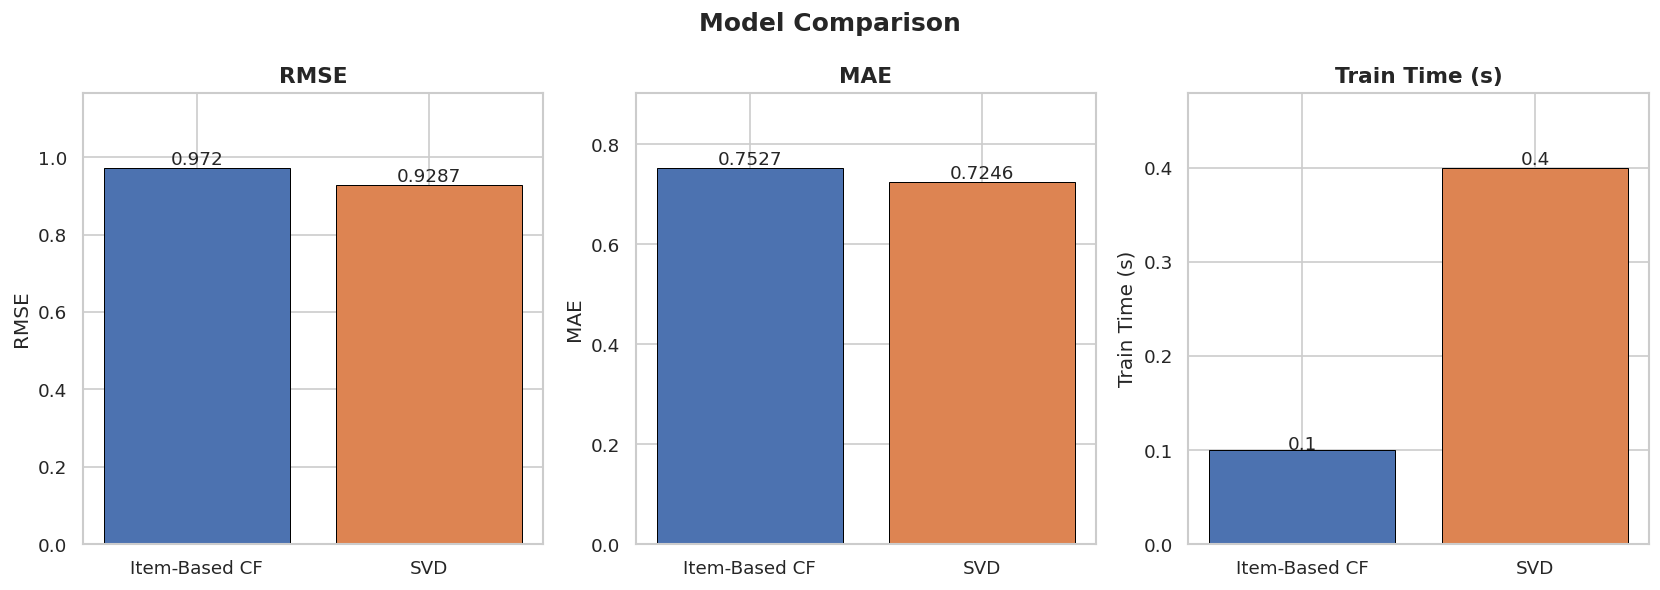

In [23]:
# ── Comparison Bar Charts ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['RMSE', 'MAE', 'Train Time (s)']
colors  = ['#4C72B0', '#DD8452']

for ax, metric in zip(axes, metrics):
    vals = comparison[metric].values
    bars = ax.bar(comparison['Model'], vals, color=colors, edgecolor='black', linewidth=0.6)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val}', ha='center', fontsize=11)
    ax.set_ylim(0, max(vals)*1.2)

plt.suptitle('Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

# ────────────────────────────────────────────
# SECTION 10: MAP@10 EVALUATION
# ────────────────────────────────────────────
##  Section 10 — MAP@10 (Ranking Quality)

**Definition:** A movie is considered **relevant** if its actual rating ≥ 3.5.  
MAP@10 measures how well the model ranks relevant movies in the top-10 recommendations.

In [24]:
RELEVANCE_THRESHOLD = 3.5
K = 10

def get_top_k_predictions(predictions, k=10):
    """Group predictions by user and return top-K predicted items per user."""
    user_preds = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_preds[uid].append((iid, est, true_r))
    # Sort each user's predictions by estimated rating descending
    top_k = {}
    for uid, preds in user_preds.items():
        preds.sort(key=lambda x: x[1], reverse=True)
        top_k[uid] = preds[:k]
    return top_k


def average_precision_at_k(user_top_k, threshold=3.5, k=10):
    """Compute Average Precision@K for a single user."""
    hits, sum_prec = 0, 0.0
    for rank, (iid, est, true_r) in enumerate(user_top_k[:k], start=1):
        if true_r >= threshold:
            hits += 1
            sum_prec += hits / rank
    n_relevant = sum(1 for _, _, r in user_top_k if r >= threshold)
    if n_relevant == 0:
        return 0.0
    return sum_prec / min(n_relevant, k)


def compute_map_at_k(predictions, threshold=3.5, k=10):
    """Compute MAP@K over all users."""
    top_k = get_top_k_predictions(predictions, k)
    ap_scores = [average_precision_at_k(v, threshold, k) for v in top_k.values()]
    return np.mean(ap_scores), top_k


map_cf,  topk_cf  = compute_map_at_k(predictions_cf,  RELEVANCE_THRESHOLD, K)
map_svd, topk_svd = compute_map_at_k(predictions_svd, RELEVANCE_THRESHOLD, K)

print(f'MAP@{K}  |  Item-CF: {map_cf:.4f}  |  SVD: {map_svd:.4f}')

MAP@10  |  Item-CF: 0.6720  |  SVD: 0.6881


In [25]:
# ── Full Metrics Summary ───────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'         : ['Item-Based CF', 'SVD'],
    'RMSE'          : [round(rmse_cf,  4), round(rmse_svd,  4)],
    'MAE'           : [round(mae_cf,   4), round(mae_svd,   4)],
    f'MAP@{K}'      : [round(map_cf,   4), round(map_svd,   4)],
    'Train Time (s)': [round(train_time_cf,1), round(train_time_svd,1)]
})
print('\n' + '='*60)
print('           FULL EVALUATION SUMMARY')
print('='*60)
print(summary.to_string(index=False))
print('='*60)
best = 'SVD' if rmse_svd < rmse_cf else 'Item-Based CF'
print(f'\n Best model by RMSE: {best}')


           FULL EVALUATION SUMMARY
        Model   RMSE    MAE  MAP@10  Train Time (s)
Item-Based CF 0.9720 0.7527  0.6720             0.1
          SVD 0.9287 0.7246  0.6881             0.4

 Best model by RMSE: SVD


# ────────────────────────────────────────────
# SECTION 11: TOP-K RECOMMENDATION GENERATION
# ────────────────────────────────────────────
##  Section 11 — Top-10 Recommendations for Sample Users

##  Generating Personalized Recommendations

The ultimate goal of a recommendation system is to identify and suggest movies that a user is likely to enjoy but has not yet interacted with.

In this section, we generate **Top-N personalized recommendations** for selected users using the trained recommendation model.

### Recommendation Strategy

The recommendation process follows these steps:

1. Identify all movies already rated by the user.
2. Exclude these movies from the candidate pool.
3. Predict ratings for all remaining unseen movies.
4. Rank movies based on their predicted ratings.
5. Return the Top-N highest-scoring recommendations.

### Why Exclude Previously Rated Movies?

Recommending movies that a user has already watched provides little practical value. Therefore, recommendations are generated only from movies that the user has not rated in the training data.

### Sample User Analysis

To demonstrate the behavior of the recommendation system, we select a small set of highly active users from the dataset.

These users typically have richer interaction histories, allowing the model to better learn their preferences and generate more personalized recommendations.

The following cell:

- Creates a recommendation function
- Predicts ratings for unseen movies
- Generates Top-N recommendations
- Selects sample users for qualitative analysis

The resulting recommendations will later be examined to assess recommendation quality, relevance, and personalization.

In [26]:
def recommend_for_user(model, trainset_obj, user_id, all_movie_ids, n=10):
    """
    Generate top-N recommendations for a user.
    Excludes movies already rated by the user in training.
    """
    # Get movies the user has already rated
    try:
        inner_uid = trainset_obj.to_inner_uid(user_id)
        rated_iids = set(trainset_obj.ur[inner_uid])
        rated_movie_ids = {trainset_obj.to_raw_iid(iid) for iid, _ in rated_iids}
    except ValueError:
        rated_movie_ids = set()

    # Predict ratings for all unrated movies
    unrated = [iid for iid in all_movie_ids if iid not in rated_movie_ids]
    preds   = [(iid, model.predict(user_id, iid).est) for iid in unrated]
    preds.sort(key=lambda x: x[1], reverse=True)
    return preds[:n]


all_movie_ids = df_filtered['movie_id'].unique().tolist()

# Pick 5 sample users
sample_users = df_filtered['user_id'].value_counts().head(5).index.tolist()
print(f'Sample users: {sample_users}')

Sample users: [305344, 387418, 2439493, 1664010, 2118461]


In [27]:
# ── Display recommendations for each sample user ──────────────────────
for uid in sample_users:
    print(f'\n{"="*55}')
    print(f'   Recommendations for User {uid}')
    print(f'{"="*55}')

    # SVD recommendations
    recs_svd = recommend_for_user(svd_model, trainset, uid, all_movie_ids, n=10)
    rec_df   = pd.DataFrame(recs_svd, columns=['movie_id', 'predicted_rating'])
    rec_df   = rec_df.merge(movies[['movie_id','title','year']], on='movie_id', how='left')
    rec_df['predicted_rating'] = rec_df['predicted_rating'].round(2)
    rec_df.index = range(1, 11)

    print(rec_df[['title', 'year', 'predicted_rating']].to_string())


   Recommendations for User 305344
                                                                          title  year  predicted_rating
1   Lord of the Rings: The Return of the King: Extended Edition: Bonus Material  2003              2.79
2                                                     Life or Something Like It  2002              2.69
3                                                    Sex and the City: Season 4  2001              2.69
4                                                          A Night at the Opera  1935              2.63
5                                         The Battle of Algiers: Bonus Material  1965              2.58
6                                                               The Deer Hunter  1978              2.58
7                                                     If These Walls Could Talk  1996              2.56
8                                     The Phantom of the Opera: Special Edition  2004              2.55
9                           

# ────────────────────────────────────────────
# SECTION 12: SUCCESS & FAILURE CASE ANALYSIS
# ────────────────────────────────────────────
##  Section 12 — Success and Failure Cases


##  Recommendation Quality Analysis

While aggregate metrics such as RMSE and MAE provide a quantitative assessment of model performance, they do not fully explain *where* the model performs well or struggles.

To gain deeper insights, we analyze individual prediction errors produced by the SVD recommendation model.

### Error Definition

For each prediction, the absolute error is calculated as:

**Absolute Error = | Actual Rating − Predicted Rating |**

Smaller errors indicate that the model successfully captured user preferences, whereas larger errors suggest a mismatch between predicted and actual behavior.

### Success Cases

A prediction is considered a **success case** when:

**|Error| < 0.5**

These cases represent situations where the predicted rating is very close to the user's actual rating, indicating strong preference modeling.

### Failure Cases

A prediction is considered a **failure case** when:

**|Error| > 2.0**

These cases highlight situations where the model substantially misjudged user preferences and may reveal limitations such as:

- Unusual user behavior
- Niche movie preferences
- Sparse interaction histories
- Insufficient latent-factor representation

### Purpose of This Analysis

This analysis helps answer several important questions:

- How often does the model make highly accurate predictions?
- How frequently does it produce large errors?
- Which movies contribute to prediction failures?
- What insights can be used to improve recommendation quality?

The following cell quantifies both success and failure cases and displays representative examples of large prediction errors for further investigation.

In [28]:
# ── Prediction error analysis ──────────────────────────────────────────
pred_df = pd.DataFrame([
    {'user_id': uid, 'movie_id': iid, 'actual': r, 'predicted': est}
    for uid, iid, r, est, _ in predictions_svd
])
pred_df['error'] = abs(pred_df['actual'] - pred_df['predicted'])

# Success cases: error < 0.5
success = pred_df[pred_df['error'] < 0.5]
# Failure cases: error > 2.0
failure = pred_df[pred_df['error'] > 2.0]

print(f' Success cases (|error| < 0.5) : {len(success):,}  ({len(success)/len(pred_df):.1%})')
print(f' Failure cases (|error| > 2.0) : {len(failure):,}  ({len(failure)/len(pred_df):.1%})')

# Show sample failures
failure_sample = failure.merge(movies[['movie_id','title']], on='movie_id', how='left').head(10)
print('\nSample failure cases:')
print(failure_sample[['user_id','title','actual','predicted','error']].to_string(index=False))

 Success cases (|error| < 0.5) : 2,772  (43.2%)
 Failure cases (|error| > 2.0) : 222  (3.5%)

Sample failure cases:
 user_id                                 title  actual  predicted    error
 1616870                              Impostor     1.0   3.663454 2.663454
  922551            What the #$*! Do We Know!?     5.0   2.791343 2.208657
  387418                  Gentlemen of Fortune     4.0   1.404959 2.595041
 2062350 The Carol Burnett Show: Show Stoppers     1.0   3.304187 2.304187
 1061195   Dr. Quinn, Medicine Woman: Season 3     1.0   3.553838 2.553838
  507094                              The Game     1.0   3.902116 2.902116
 2238060                      Antarctica: IMAX     2.0   4.208429 2.208429
  952063            Chappelle's Show: Season 1     5.0   2.598148 2.401852
 1061195                              Impostor     1.0   3.333625 2.333625
 2541025            Sex and the City: Season 4     5.0   1.386510 3.613490


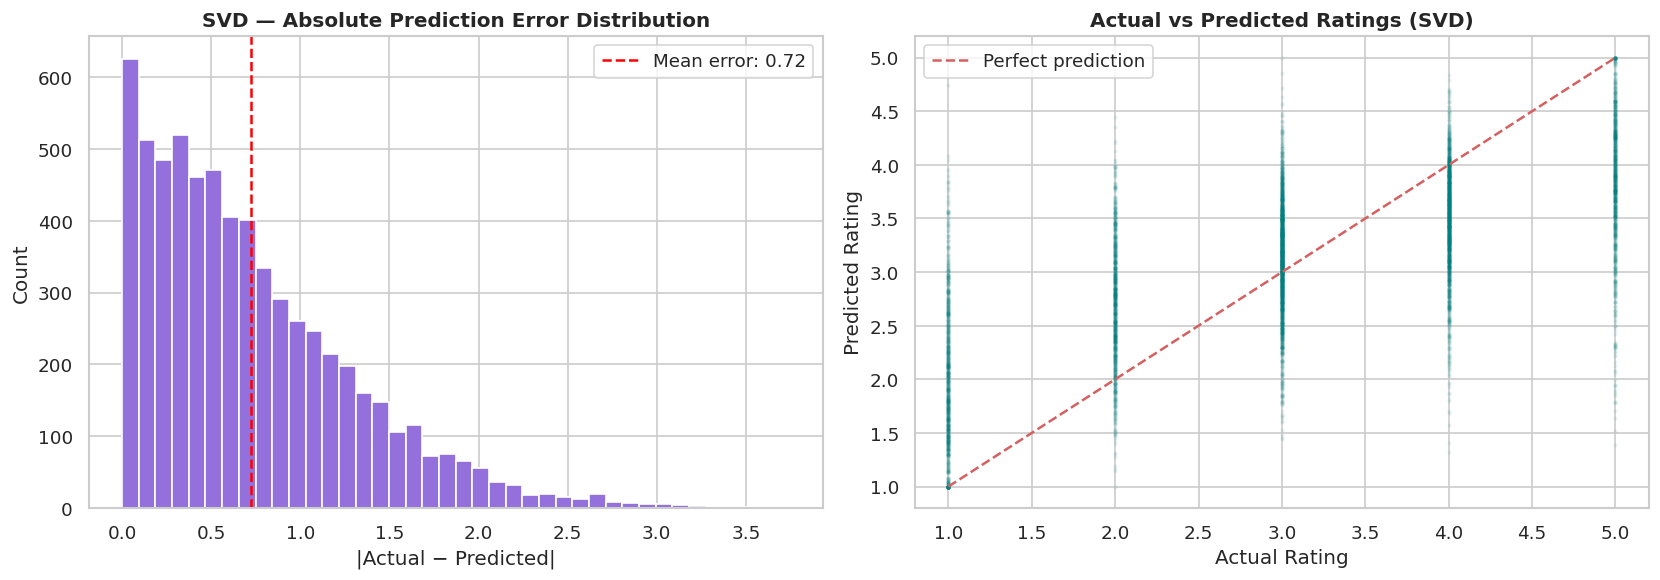

In [29]:
# ── Error Distribution Plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pred_df['error'], bins=40, color='mediumpurple', edgecolor='white')
axes[0].axvline(pred_df['error'].mean(), color='red', linestyle='--',
                label=f'Mean error: {pred_df["error"].mean():.2f}')
axes[0].set_title('SVD — Absolute Prediction Error Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('|Actual − Predicted|')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].scatter(pred_df['actual'], pred_df['predicted'],
                alpha=0.05, s=3, color='teal')
axes[1].plot([1,5],[1,5], 'r--', linewidth=1.5, label='Perfect prediction')
axes[1].set_title('Actual vs Predicted Ratings (SVD)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].legend()

plt.tight_layout()
plt.savefig('error_analysis.png', bbox_inches='tight')
plt.show()

# ────────────────────────────────────────────
# SECTION 13: OPTIONAL — EXPLAINABLE RECOMMENDATIONS
# ────────────────────────────────────────────
##  Section 13 — Explainable Recommendations (Optional)

Using Item-CF similarity, we can explain *why* a movie was recommended.

In [30]:
def explain_recommendation(model, trainset_obj, user_id, target_movie_id, n_explain=3):
    """
    Explain why target_movie_id was recommended to user_id.
    Shows the most similar movies that the user has already rated highly.
    """
    try:
        inner_uid  = trainset_obj.to_inner_uid(user_id)
        inner_iid  = trainset_obj.to_inner_iid(target_movie_id)
    except ValueError:
        print('User or movie not in training set.')
        return

    # Get movies user has rated in training
    user_rated = trainset_obj.ur[inner_uid]   # list of (inner_iid, rating)

    # Get top similar movies to target
    neighbors = model.get_neighbors(inner_iid, k=20)

    # Find overlap: neighbors that the user has rated
    user_rated_iids = {iid for iid, _ in user_rated}
    overlap = [(iid, dict(user_rated).get(iid, None)) for iid in neighbors if iid in user_rated_iids]
    overlap = sorted(overlap, key=lambda x: x[1] if x[1] else 0, reverse=True)[:n_explain]

    target_title = movies[movies['movie_id'] == target_movie_id]['title'].values
    target_title = target_title[0] if len(target_title) else str(target_movie_id)

    print(f'\n Why was "{target_title}" recommended to User {user_id}?')
    print('   Because they liked:')
    for inner, r in overlap:
        raw_iid = trainset_obj.to_raw_iid(inner)
        t = movies[movies['movie_id'] == raw_iid]['title'].values
        t = t[0] if len(t) else str(raw_iid)
        print(f'      "{t}"  (rated {r:.1f}/5)')


# Example: explain the first recommendation for first sample user
uid_demo = sample_users[0]
recs_cf  = recommend_for_user(item_cf, trainset, uid_demo, all_movie_ids, n=10)
if recs_cf:
    explain_recommendation(item_cf, trainset, uid_demo, recs_cf[0][0])


 Why was "Lord of the Rings: The Return of the King: Extended Edition: Bonus Material" recommended to User 305344?
   Because they liked:
      "North by Northwest"  (rated 4.0/5)
      "Cast a Giant Shadow"  (rated 4.0/5)
      "The Devil's Brigade"  (rated 3.0/5)


# ────────────────────────────────────────────
# SECTION 14: COLD START DISCUSSION
# ────────────────────────────────────────────
##  Section 14 — Cold Start Problem (Optional Discussion)

### What is the Cold Start Problem?
- **New user cold start:** A new user has no rating history, so collaborative filtering cannot make personalized recommendations.
- **New item cold start:** A new movie has no ratings, so it cannot be included in similarity calculations.

### Strategies to Handle Cold Start

| Strategy | Approach |
|---|---|
| **Popularity-based fallback** | Recommend globally popular movies to new users |
| **Demographic filtering** | Use age, location, device type to infer preferences |
| **Content-based filtering** | Use movie genre, cast, director metadata |
| **Onboarding ratings** | Ask new users to rate a few seed movies |
| **Hybrid systems** | Combine collaborative + content-based models |
| **Transfer learning** | Pre-train on similar datasets |


In [31]:
# ── Cold start: popularity-based fallback for new users ────────────────
def recommend_cold_start(df_train, movies_df, n=10, min_ratings=50):
    """
    For new users: recommend top-N globally popular and well-rated movies.
    min_ratings lowered to 50 to work with sampled dataset.
    """
    stats = df_train.groupby('movie_id').agg(
        avg_rating=('rating', 'mean'),
        num_ratings=('rating', 'count')
    ).reset_index()

    # Auto-adjust threshold if too strict
    if stats[stats['num_ratings'] >= min_ratings].empty:
        min_ratings = int(stats['num_ratings'].quantile(0.75))
        print(f'  Threshold auto-adjusted to {min_ratings} ratings')

    stats = stats[stats['num_ratings'] >= min_ratings]

    # Bayesian average
    C = stats['num_ratings'].mean()
    m = stats['avg_rating'].mean()
    stats['bayesian_score'] = (
        (stats['num_ratings'] * stats['avg_rating'] + C * m) /
        (stats['num_ratings'] + C)
    )

    top = stats.sort_values('bayesian_score', ascending=False).head(n)
    top = top.merge(movies_df[['movie_id','title','year']], on='movie_id', how='left')
    top = top.reset_index(drop=True)        # ← fixes the index error
    top.index = range(1, len(top) + 1)      # ← safe index assignment

    return top[['title', 'year', 'bayesian_score', 'num_ratings']]


cold_start_recs = recommend_cold_start(df_filtered, movies)
print('  Cold Start Recommendations (for new users):')
print(cold_start_recs.to_string())

  Cold Start Recommendations (for new users):
                                      title  year  bayesian_score  num_ratings
1                          X2: X-Men United  2003        3.680206          426
2                        North by Northwest  1959        3.652222          341
3                            Reservoir Dogs  1992        3.571334          397
4                           The Deer Hunter  1978        3.524311          375
5                    Something's Gotta Give  2003        3.485133          396
6                      A Night at the Opera  1935        3.435881          175
7                           Lilo and Stitch  2002        3.430383          342
8                     I Love Lucy: Season 2  1952        3.423017          183
9   Richard Pryor: Live on the Sunset Strip  1982        3.413998          222
10                                 The Game  1997        3.413752          418


# ────────────────────────────────────────────
# SECTION 15: CONCLUSION & FUTURE WORK
# ────────────────────────────────────────────
##  Section 15 — Conclusion

In [32]:
print('='*60)
print('           FINAL RESULTS SUMMARY')
print('='*60)
print(summary.to_string(index=False))
print('='*60)

print("""
 Key Observations:
───────────────────────────────────────────────────────────
1. Rating distribution is left-skewed — users prefer to rate
   movies they actually liked (3–5 stars dominate).

2. Dataset is highly sparse — most users have rated only a
   tiny fraction of available movies.

3. SVD outperforms Item-CF on RMSE by capturing latent
   user-movie interaction patterns more effectively.

4. Item-CF is more interpretable — recommendations can be
   explained via similar movies the user has already rated.

5. Cold start remains a challenge — popularity-based fallback
   is a reasonable baseline for new users.

 Future Improvements:
───────────────────────────────────────────────────────────
• Neural Collaborative Filtering (NCF) using embeddings
• Two-tower deep learning model for scalability
• Hybrid model combining SVD + content-based features
• Real-time recommendation with implicit feedback
• A/B testing framework to evaluate online performance
""")

           FINAL RESULTS SUMMARY
        Model   RMSE    MAE  MAP@10  Train Time (s)
Item-Based CF 0.9720 0.7527  0.6720             0.1
          SVD 0.9287 0.7246  0.6881             0.4

 Key Observations:
───────────────────────────────────────────────────────────
1. Rating distribution is left-skewed — users prefer to rate
   movies they actually liked (3–5 stars dominate).

2. Dataset is highly sparse — most users have rated only a
   tiny fraction of available movies.

3. SVD outperforms Item-CF on RMSE by capturing latent
   user-movie interaction patterns more effectively.

4. Item-CF is more interpretable — recommendations can be
   explained via similar movies the user has already rated.

5. Cold start remains a challenge — popularity-based fallback
   is a reasonable baseline for new users.

 Future Improvements:
───────────────────────────────────────────────────────────
• Neural Collaborative Filtering (NCF) using embeddings
• Two-tower deep learning model for scalability